# 10 - Additional Paper Figures

This notebook generates two descriptive figures for the lung cancer paper:

1. A rank-ordered county-year heatmap of lung cancer mortality
2. A formaldehyde cluster case-study figure

These figures are descriptive only. They do not retrain models or alter outputs from notebooks `00-09`.


In [7]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

OUTPUT_DIR = Path('../data/outputs/paper_additions')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DPI = 600
FONT_SIZE = 11
DOUBLE_COL_WIDTH = 6.85
HEATMAP_CMAP = 'magma'
TOP10_COLOR = '#F97360'
OTHER_COLOR = '#2D9CDB'
TITLE_COLOR = '#1F2937'

plt.rcParams['font.size'] = FONT_SIZE
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['savefig.facecolor'] = 'white'
plt.rcParams['grid.color'] = '#E2E8F0'
plt.rcParams['grid.linewidth'] = 0.7
plt.rcParams['grid.alpha'] = 0.45
sns.set_style('whitegrid')

print(f'Output directory: {OUTPUT_DIR.resolve()}')


Output directory: /Users/samyakshrestha/Projects/predicting-lung-cancer/data/outputs/paper_additions


## 1. Rank-Ordered County-Year Heatmap

Use the balanced lung-cancer-only panel from `data/processed/preprocessed_fips_lung_cancer/`.
County rank is fixed using each county's mean lung cancer mortality across 2012-2019.


In [8]:
heatmap_input_dir = Path('../data/processed/preprocessed_fips_lung_cancer')
heatmap_files = sorted(heatmap_input_dir.glob('preprocessed_lung_cancer_fips_*.csv'))

heatmap_frames = []
for file_path in heatmap_files:
    df_year = pd.read_csv(
        file_path,
        dtype={'Fips': str, 'State_FIPS': str, 'County_FIPS': str}
    )
    df_year['Fips'] = df_year['Fips'].astype(str).str.zfill(5)
    df_year['year'] = df_year['year'].astype(int)
    df_year['lung_cancer_mortality_per_100k'] = df_year['lung_cancer_mortality_rate'] * 100000
    heatmap_frames.append(
        df_year[['Fips', 'County', 'State', 'year', 'lung_cancer_mortality_per_100k']].copy()
    )

heatmap_panel = pd.concat(heatmap_frames, ignore_index=True)
heatmap_panel = heatmap_panel.rename(columns={'Fips': 'fips'})

year_counts = heatmap_panel.groupby('year')['fips'].nunique().sort_index()
expected_years = list(range(2012, 2020))

assert heatmap_panel['year'].nunique() == 8, 'Expected 8 years in heatmap panel'
assert list(year_counts.index) == expected_years, 'Heatmap panel years are not 2012-2019'
assert (year_counts == 3111).all(), 'Heatmap panel must have 3111 counties in each year'

county_rank_df = (
    heatmap_panel
    .groupby(['fips', 'County', 'State'], as_index=False)['lung_cancer_mortality_per_100k']
    .mean()
    .rename(columns={'lung_cancer_mortality_per_100k': 'mean_mortality_per_100k'})
    .sort_values('mean_mortality_per_100k', ascending=False)
    .reset_index(drop=True)
)
county_rank_df['county_rank'] = np.arange(1, len(county_rank_df) + 1)

heatmap_ranked = heatmap_panel.merge(
    county_rank_df[['fips', 'county_rank']],
    on='fips',
    how='left'
)

heatmap_matrix = (
    heatmap_ranked
    .pivot(index='county_rank', columns='year', values='lung_cancer_mortality_per_100k')
    .sort_index()
)

assert heatmap_matrix.shape == (3111, 8), 'Unexpected heatmap matrix shape'
assert not heatmap_matrix.isna().any().any(), 'Heatmap matrix contains missing values'

print('Heatmap input verification')
print('--------------------------')
print(year_counts.to_string())
print(f'Heatmap matrix shape: {heatmap_matrix.shape}')
print('\nTop 10 counties by mean 2012-2019 lung cancer mortality (per 100,000):')
print(county_rank_df[['county_rank', 'County', 'State', 'mean_mortality_per_100k']].head(10).to_string(index=False))


Heatmap input verification
--------------------------
year
2012    3111
2013    3111
2014    3111
2015    3111
2016    3111
2017    3111
2018    3111
2019    3111
Heatmap matrix shape: (3111, 8)

Top 10 counties by mean 2012-2019 lung cancer mortality (per 100,000):
 county_rank          County    State  mean_mortality_per_100k
           1    Union County  Florida               136.948453
           2    Perry County Kentucky               125.010300
           3 McCreary County Kentucky               116.369492
           4   Leslie County Kentucky               115.966724
           5   Harlan County Kentucky               112.193088
           6    Floyd County Kentucky               111.797301
           7     Clay County Kentucky               110.953733
           8   Powell County Kentucky               108.800792
           9      Lee County Kentucky               108.108221
          10   Owsley County Kentucky               107.595704


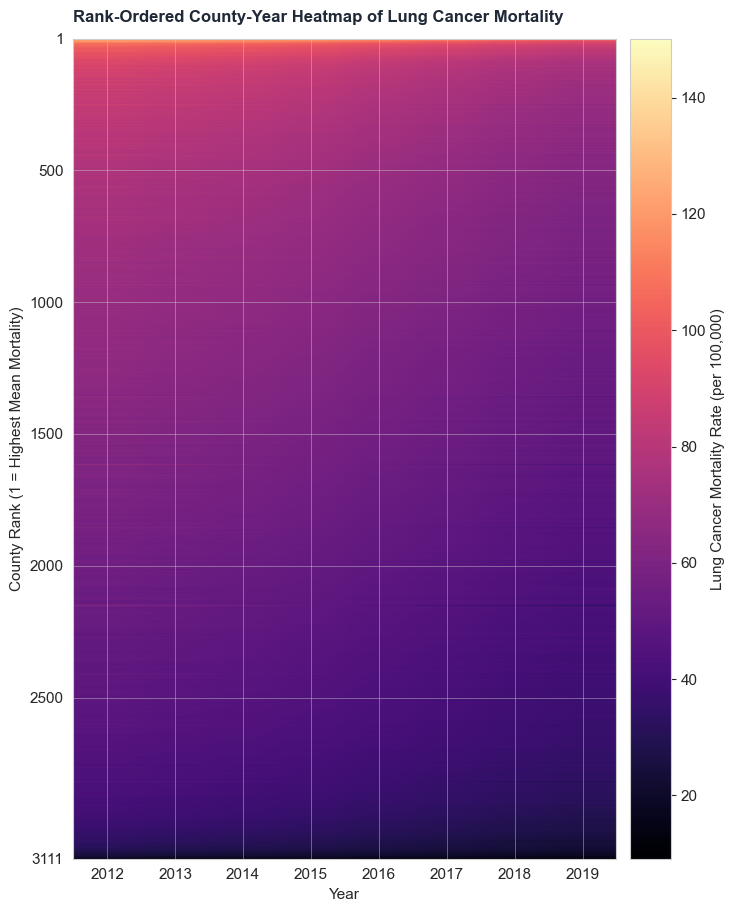

Saved: /Users/samyakshrestha/Projects/predicting-lung-cancer/data/outputs/paper_additions/fig29_ranked_county_year_heatmap.png


In [9]:
fig, ax = plt.subplots(figsize=(DOUBLE_COL_WIDTH * 1.10, 9.25))

im = ax.imshow(
    heatmap_matrix.values,
    aspect='auto',
    cmap=HEATMAP_CMAP,
    origin='upper',
    vmin=heatmap_matrix.values.min(),
    vmax=heatmap_matrix.values.max()
)

years = heatmap_matrix.columns.tolist()
ax.set_xticks(np.arange(len(years)))
ax.set_xticklabels(years)

y_tick_positions = [0, 499, 999, 1499, 1999, 2499, 3110]
y_tick_labels = ['1', '500', '1000', '1500', '2000', '2500', '3111']
ax.set_yticks(y_tick_positions)
ax.set_yticklabels(y_tick_labels)

ax.set_xlabel('Year')
ax.set_ylabel('County Rank (1 = Highest Mean Mortality)')
ax.set_title(
    'Rank-Ordered County-Year Heatmap of Lung Cancer Mortality',
    loc='left',
    fontsize=FONT_SIZE + 1,
    fontweight='bold',
    color=TITLE_COLOR,
    pad=12
)

cbar = plt.colorbar(im, ax=ax, pad=0.02)
cbar.set_label('Lung Cancer Mortality Rate (per 100,000)')

plt.tight_layout()
heatmap_path = OUTPUT_DIR / 'fig29_ranked_county_year_heatmap.png'
plt.savefig(heatmap_path, dpi=DPI, bbox_inches='tight', facecolor='white')
plt.show()

print(f'Saved: {heatmap_path.resolve()}')


## 2. Formaldehyde Cluster Case Study

Define the case-study counties as the top 10 counties by mean 2012-2019 `FoT Formaldehyde above75ᵗʰ percentile` in the final merged dataset.


In [10]:
merged_path = Path('../data/combined_final/final_combined_all_variables.csv')
merged_df = pd.read_csv(merged_path, dtype={'fips': str})
merged_df['fips'] = merged_df['fips'].astype(str).str.zfill(5)

formaldehyde_col = 'FoT Formaldehyde above75ᵗʰ percentile'
smoking_col = 'Smoking Rate'
wet_bulb_col = 'Wet bulb temperature'
target_col = 'Lung Cancer Mortality Rate'

required_columns = [formaldehyde_col, smoking_col, wet_bulb_col, target_col, 'County', 'State', 'Year', 'fips']
missing_columns = [column for column in required_columns if column not in merged_df.columns]
assert not missing_columns, f'Missing required columns: {missing_columns}'

merged_df['Year'] = merged_df['Year'].astype(int)
merged_df['lung_cancer_mortality_per_100k'] = merged_df[target_col] * 100000

top10_formaldehyde_df = (
    merged_df
    .groupby(['fips', 'County', 'State'], as_index=False)
    .agg(
        mean_formaldehyde=(formaldehyde_col, 'mean'),
        mean_lung_cancer_mortality_per_100k=('lung_cancer_mortality_per_100k', 'mean'),
        mean_smoking_rate=(smoking_col, 'mean'),
        mean_wet_bulb_temperature=(wet_bulb_col, 'mean'),
        n_years=('Year', 'nunique')
    )
    .sort_values('mean_formaldehyde', ascending=False)
    .reset_index(drop=True)
    .head(10)
)

assert len(top10_formaldehyde_df) == 10, 'Expected exactly 10 case-study counties'
assert (top10_formaldehyde_df['n_years'] == 8).all(), 'Each top-10 case-study county must have all 8 years'

table6_df = top10_formaldehyde_df[[
    'fips',
    'County',
    'State',
    'mean_formaldehyde',
    'mean_lung_cancer_mortality_per_100k',
    'mean_smoking_rate',
    'mean_wet_bulb_temperature'
]].copy()

table6_path = OUTPUT_DIR / 'table6_top10_formaldehyde_counties.csv'
table6_df.to_csv(table6_path, index=False)

top10_fips = top10_formaldehyde_df['fips'].tolist()
case_study_top10 = merged_df[merged_df['fips'].isin(top10_fips)].copy()
case_study_other = merged_df[~merged_df['fips'].isin(top10_fips)].copy()

top10_counts = case_study_top10.groupby('Year')['fips'].nunique().sort_index()
assert (top10_counts == 10).all(), 'Top-10 case-study counties must appear in every year'

top10_mean_by_year = (
    case_study_top10
    .groupby('Year', as_index=False)
    .agg(
        formaldehyde=(formaldehyde_col, 'mean'),
        smoking_rate=(smoking_col, 'mean'),
        wet_bulb_temperature=(wet_bulb_col, 'mean'),
        lung_cancer_mortality_per_100k=('lung_cancer_mortality_per_100k', 'mean')
    )
)

other_mean_by_year = (
    case_study_other
    .groupby('Year', as_index=False)
    .agg(
        formaldehyde=(formaldehyde_col, 'mean'),
        smoking_rate=(smoking_col, 'mean'),
        wet_bulb_temperature=(wet_bulb_col, 'mean'),
        lung_cancer_mortality_per_100k=('lung_cancer_mortality_per_100k', 'mean')
    )
)

assert top10_mean_by_year.shape[0] == 8, 'Top-10 yearly summary must have 8 rows'
assert other_mean_by_year.shape[0] == 8, 'Other-county yearly summary must have 8 rows'

print('Top 10 formaldehyde counties')
print('----------------------------')
print(table6_df.to_string(index=False))
print(f'\nSaved: {table6_path.resolve()}')


Top 10 formaldehyde counties
----------------------------
 fips            County   State  mean_formaldehyde  mean_lung_cancer_mortality_per_100k  mean_smoking_rate  mean_wet_bulb_temperature
01085    Lowndes County Alabama          51.728873                            66.955647           0.224802                  15.075989
01047     Dallas County Alabama          51.620538                            75.357322           0.219025                  14.942344
01101 Montgomery County Alabama          51.595034                            57.820642           0.196521                  14.900722
01001    Autauga County Alabama          51.483432                            65.684009           0.207287                  14.928490
01087      Macon County Alabama          51.480092                            66.762065           0.178135                  14.849166
01109       Pike County Alabama          51.331911                            63.647858           0.206674                  15.532737
0110

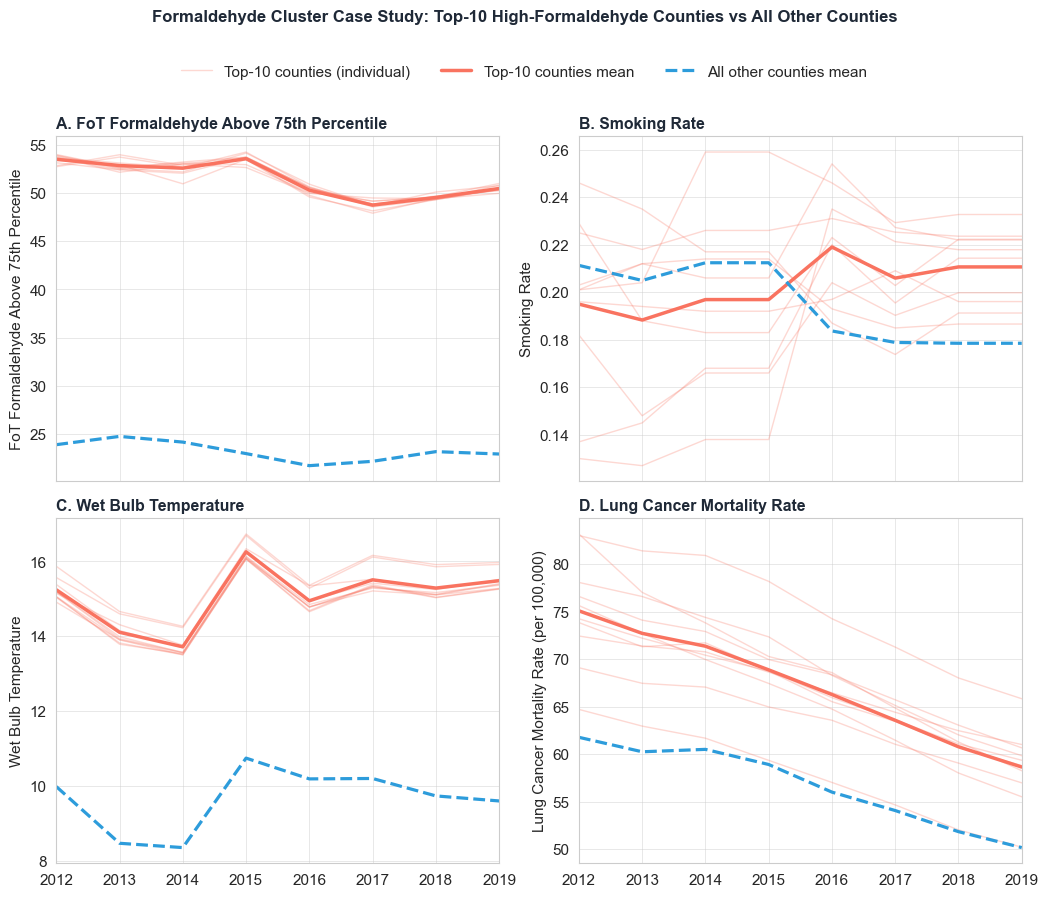

Saved: /Users/samyakshrestha/Projects/predicting-lung-cancer/data/outputs/paper_additions/fig30_formaldehyde_cluster_case_study.png


In [11]:
panel_specs = [
    ('formaldehyde', formaldehyde_col, 'A. FoT Formaldehyde Above 75th Percentile', 'FoT Formaldehyde Above 75th Percentile'),
    ('smoking_rate', smoking_col, 'B. Smoking Rate', 'Smoking Rate'),
    ('wet_bulb_temperature', wet_bulb_col, 'C. Wet Bulb Temperature', 'Wet Bulb Temperature'),
    ('lung_cancer_mortality_per_100k', 'lung_cancer_mortality_per_100k', 'D. Lung Cancer Mortality Rate', 'Lung Cancer Mortality Rate (per 100,000)')
]

fig, axes = plt.subplots(2, 2, figsize=(DOUBLE_COL_WIDTH * 1.55, DOUBLE_COL_WIDTH * 1.22), sharex=True)
axes = axes.flatten()

for ax, (summary_col, county_col, title, y_label) in zip(axes, panel_specs):
    for _, county_df in case_study_top10.groupby('fips'):
        county_df = county_df.sort_values('Year')
        ax.plot(
            county_df['Year'],
            county_df[county_col],
            color=TOP10_COLOR,
            alpha=0.28,
            linewidth=1.0
        )

    ax.plot(
        top10_mean_by_year['Year'],
        top10_mean_by_year[summary_col],
        color=TOP10_COLOR,
        linewidth=2.5
    )
    ax.plot(
        other_mean_by_year['Year'],
        other_mean_by_year[summary_col],
        color=OTHER_COLOR,
        linewidth=2.3,
        linestyle='--'
    )

    ax.set_title(title, fontsize=FONT_SIZE + 0.4, fontweight='bold', color=TITLE_COLOR, loc='left')
    ax.set_ylabel(y_label)
    ax.set_xticks(range(2012, 2020))
    ax.set_xlim(2012, 2019)
    ax.grid(True)
    ax.set_axisbelow(True)

legend_handles = [
    Line2D([0], [0], color=TOP10_COLOR, linewidth=1.0, alpha=0.28, label='Top-10 counties (individual)'),
    Line2D([0], [0], color=TOP10_COLOR, linewidth=2.5, label='Top-10 counties mean'),
    Line2D([0], [0], color=OTHER_COLOR, linewidth=2.3, linestyle='--', label='All other counties mean')
]

fig.legend(handles=legend_handles, loc='upper center', ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.02))
fig.suptitle(
    'Formaldehyde Cluster Case Study: Top-10 High-Formaldehyde Counties vs All Other Counties',
    fontsize=FONT_SIZE + 1,
    fontweight='bold',
    color=TITLE_COLOR,
    y=1.07
)

plt.tight_layout()
case_study_path = OUTPUT_DIR / 'fig30_formaldehyde_cluster_case_study.png'
plt.savefig(case_study_path, dpi=DPI, bbox_inches='tight', facecolor='white')
plt.show()

print(f'Saved: {case_study_path.resolve()}')


## 1B. County-Year Anomaly Heatmap

This variant centers each county around its own 2012-2019 mean lung cancer mortality.
It highlights whether a county-year is above or below that county's long-run baseline,
while preserving the same fixed county rank order used in the absolute heatmap.


Anomaly heatmap verification
----------------------------
Anomaly matrix shape: (3111, 8)
Min anomaly: -20.26
Max anomaly: 21.26
Symmetric color limit (99th percentile): ±9.90


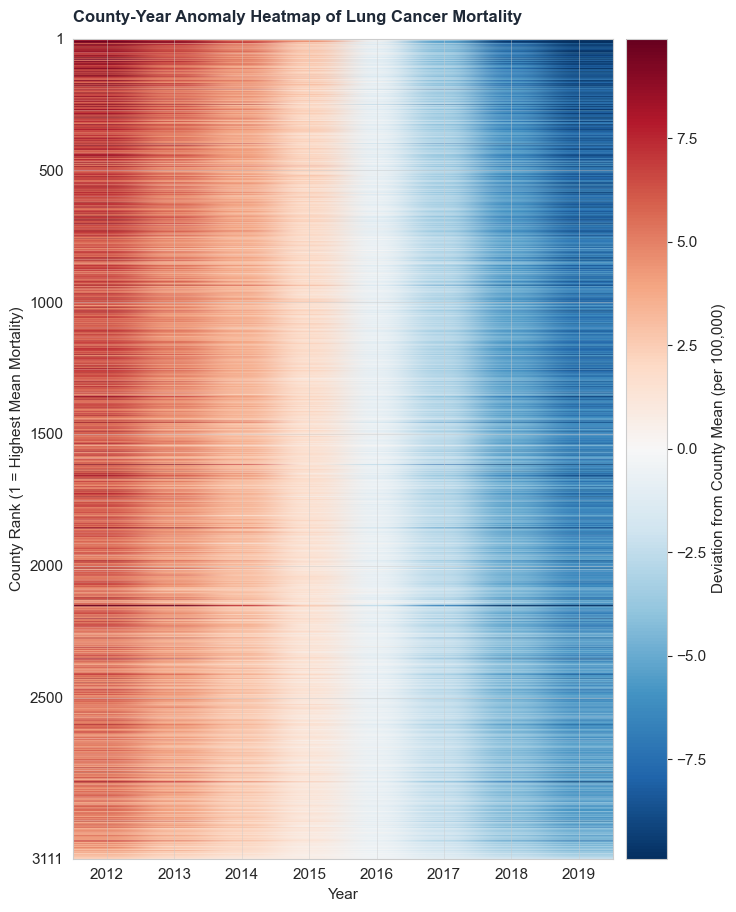

Saved: /Users/samyakshrestha/Projects/predicting-lung-cancer/data/outputs/paper_additions/fig29b_ranked_county_year_anomaly_heatmap.png


In [12]:
heatmap_anomaly = heatmap_ranked.merge(
    county_rank_df[['fips', 'mean_mortality_per_100k']],
    on='fips',
    how='left'
)
heatmap_anomaly['mortality_anomaly_per_100k'] = (
    heatmap_anomaly['lung_cancer_mortality_per_100k'] - heatmap_anomaly['mean_mortality_per_100k']
)

anomaly_matrix = (
    heatmap_anomaly
    .pivot(index='county_rank', columns='year', values='mortality_anomaly_per_100k')
    .sort_index()
)

assert anomaly_matrix.shape == (3111, 8), 'Unexpected anomaly matrix shape'
assert anomaly_matrix.index.equals(heatmap_matrix.index), 'Anomaly matrix row order must match heatmap matrix'
assert anomaly_matrix.columns.equals(heatmap_matrix.columns), 'Anomaly matrix columns must match heatmap matrix'
assert not anomaly_matrix.isna().any().any(), 'Anomaly matrix contains missing values'

anomaly_values = anomaly_matrix.to_numpy()
abs_limit = np.nanpercentile(np.abs(anomaly_values), 99)
if abs_limit == 0:
    abs_limit = np.max(np.abs(anomaly_values))
if abs_limit == 0:
    abs_limit = 1.0

print('Anomaly heatmap verification')
print('----------------------------')
print(f'Anomaly matrix shape: {anomaly_matrix.shape}')
print(f'Min anomaly: {anomaly_values.min():.2f}')
print(f'Max anomaly: {anomaly_values.max():.2f}')
print(f'Symmetric color limit (99th percentile): ±{abs_limit:.2f}')

fig, ax = plt.subplots(figsize=(DOUBLE_COL_WIDTH * 1.10, 9.25))

im = ax.imshow(
    anomaly_matrix.values,
    aspect='auto',
    cmap='RdBu_r',
    origin='upper',
    vmin=-abs_limit,
    vmax=abs_limit
)

years = anomaly_matrix.columns.tolist()
ax.set_xticks(np.arange(len(years)))
ax.set_xticklabels(years)

y_tick_positions = [0, 499, 999, 1499, 1999, 2499, 3110]
y_tick_labels = ['1', '500', '1000', '1500', '2000', '2500', '3111']
ax.set_yticks(y_tick_positions)
ax.set_yticklabels(y_tick_labels)

ax.set_xlabel('Year')
ax.set_ylabel('County Rank (1 = Highest Mean Mortality)')
ax.set_title(
    'County-Year Anomaly Heatmap of Lung Cancer Mortality',
    loc='left',
    fontsize=FONT_SIZE + 1,
    fontweight='bold',
    color=TITLE_COLOR,
    pad=12
)

cbar = plt.colorbar(im, ax=ax, pad=0.02)
cbar.set_label('Deviation from County Mean (per 100,000)')

plt.tight_layout()
anomaly_path = OUTPUT_DIR / 'fig29b_ranked_county_year_anomaly_heatmap.png'
plt.savefig(anomaly_path, dpi=DPI, bbox_inches='tight', facecolor='white')
plt.show()

print(f'Saved: {anomaly_path.resolve()}')


## 3. Final Verification

Confirm output files exist and that the case-study county set is complete across all 8 years.


In [13]:
output_files = [
    OUTPUT_DIR / 'fig29_ranked_county_year_heatmap.png',
    OUTPUT_DIR / 'fig29b_ranked_county_year_anomaly_heatmap.png',
    OUTPUT_DIR / 'fig30_formaldehyde_cluster_case_study.png',
    OUTPUT_DIR / 'table6_top10_formaldehyde_counties.csv'
]

print('Final verification')
print('------------------')
print(f'Heatmap matrix shape: {heatmap_matrix.shape}')
print(f'Top-10 case-study counties: {len(top10_fips)}')
print('\nTop-10 county year coverage:')
print(top10_counts.to_string())
print('\nOutput files:')
for file_path in output_files:
    exists = file_path.exists()
    size_kb = file_path.stat().st_size / 1024 if exists else np.nan
    print(f'  - {file_path.name}: exists={exists}, size_kb={size_kb:.1f}')


Final verification
------------------
Heatmap matrix shape: (3111, 8)
Top-10 case-study counties: 10

Top-10 county year coverage:
Year
2012    10
2013    10
2014    10
2015    10
2016    10
2017    10
2018    10
2019    10

Output files:
  - fig29_ranked_county_year_heatmap.png: exists=True, size_kb=1364.7
  - fig29b_ranked_county_year_anomaly_heatmap.png: exists=True, size_kb=4530.7
  - fig30_formaldehyde_cluster_case_study.png: exists=True, size_kb=1720.3
  - table6_top10_formaldehyde_counties.csv: exists=True, size_kb=1.1
